<a href="https://colab.research.google.com/github/Alishba-12/AI-ML_02_SpamSMSClassifier_byte/blob/main/Spam_SMS_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Cell 1: Install and import libraries
!pip install pandas numpy matplotlib seaborn scikit-learn nltk wordcloud

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.pipeline import Pipeline
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
import re
import string
from wordcloud import WordCloud
import joblib
import pickle
import os
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')

print("✅ All libraries installed and imported successfully!")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


✅ All libraries installed and imported successfully!


--2026-09-04 08:07:00--  https://raw.githubusercontent.com/justmarkham/pydata-dc-2016-tutorial/master/sms.tsv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 477907 (467K) [text/plain]
Saving to: ‘spam.csv’

spam.csv            100%[===================>] 466.71K  --.-KB/s    in 0.03s   

2026-09-04 08:07:00 (16.8 MB/s) - ‘spam.csv’ saved [477907/477907]

📊 DATASET INFORMATION
Total samples: 5572
Spam messages: 747
Ham messages: 4825
Spam percentage: 13.41%

📋 First 5 samples:
  label                                            message  label_num
0   ham  Go until jurong point, crazy.. Available only ...          0
1   ham                      Ok lar... Joking wif u oni...          0
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...          1
3   ham

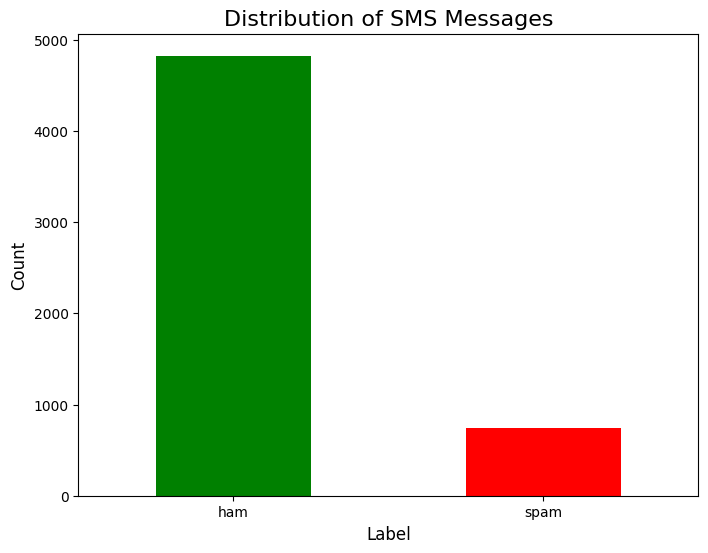

In [ ]:
# Cell 2: Load and explore dataset

# Option 1: Load from UCI (SMS Spam Collection)
!wget -O spam.csv https://raw.githubusercontent.com/justmarkham/pydata-dc-2016-tutorial/master/sms.tsv

# Read the dataset
data = pd.read_csv('spam.csv', encoding='latin-1', sep='\t', header=None)
data.columns = ['label', 'message']

# Keep only the first two columns
data = data[['label', 'message']]

# Map labels: ham -> 0 (not spam), spam -> 1 (spam)
data['label_num'] = data['label'].map({'ham': 0, 'spam': 1})

# Display dataset info
print("="*50)
print("📊 DATASET INFORMATION")
print("="*50)
print(f"Total samples: {len(data)}")
print(f"Spam messages: {data[data['label'] == 'spam'].shape[0]}")
print(f"Ham messages: {data[data['label'] == 'ham'].shape[0]}")
print(f"Spam percentage: {data[data['label'] == 'spam'].shape[0] / len(data) * 100:.2f}%")

print("\n📋 First 5 samples:")
print(data.head())

print("\n📊 Label distribution:")
print(data['label'].value_counts())

# Visualize distribution
plt.figure(figsize=(8, 6))
data['label'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Distribution of SMS Messages', fontsize=16)
plt.xlabel('Label', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)
plt.show()

In [3]:
# Cell 3: Text Preprocessing Functions

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
import re
import string

# Download NLTK data
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')

def clean_text(text):
    """
    Clean and preprocess text message
    """
    # Convert to lowercase
    text = text.lower()

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

def remove_stopwords(text):
    """
    Remove stopwords from text
    """
    stop_words = set(stopwords.words('english'))
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return ' '.join(words)

def stem_text(text):
    """
    Apply stemming to text
    """
    stemmer = PorterStemmer()
    words = text.split()
    words = [stemmer.stem(word) for word in words]
    return ' '.join(words)

def lemmatize_text(text):
    """
    Apply lemmatization to text
    """
    lemmatizer = WordNetLemmatizer()
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words]
    return ' '.join(words)

# Apply preprocessing
print("🔧 Preprocessing messages...")

# Clean text
data['cleaned_text'] = data['message'].apply(clean_text)

# Remove stopwords
data['cleaned_text'] = data['cleaned_text'].apply(remove_stopwords)

# Apply stemming (optional - uncomment if needed)
# data['cleaned_text'] = data['cleaned_text'].apply(stem_text)

# Show sample before and after
print("\n📝 Sample preprocessing:")
sample_idx = 0
print(f"Original: {data['message'].iloc[sample_idx]}")
print(f"Cleaned: {data['cleaned_text'].iloc[sample_idx]}")

print("\n✅ Preprocessing complete!")
print(f"Average length before: {data['message'].str.len().mean():.0f} characters")
print(f"Average length after: {data['cleaned_text'].str.len().mean():.0f} characters")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


🔧 Preprocessing messages...

📝 Sample preprocessing:
Original: Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
Cleaned: go jurong point crazy available bugis n great world la e buffet cine got amore wat

✅ Preprocessing complete!
Average length before: 81 characters
Average length after: 51 characters


📊 EXPLORATORY DATA ANALYSIS

🔝 Top 10 most common words:
u       1156
call     580
im       466
ur       390
get      390
dont     287
go       285
free     278
ok       278
ltgt     276
Name: count, dtype: int64

📏 Message length analysis:
Average length (ham): 45.61
Average length (spam): 89.47


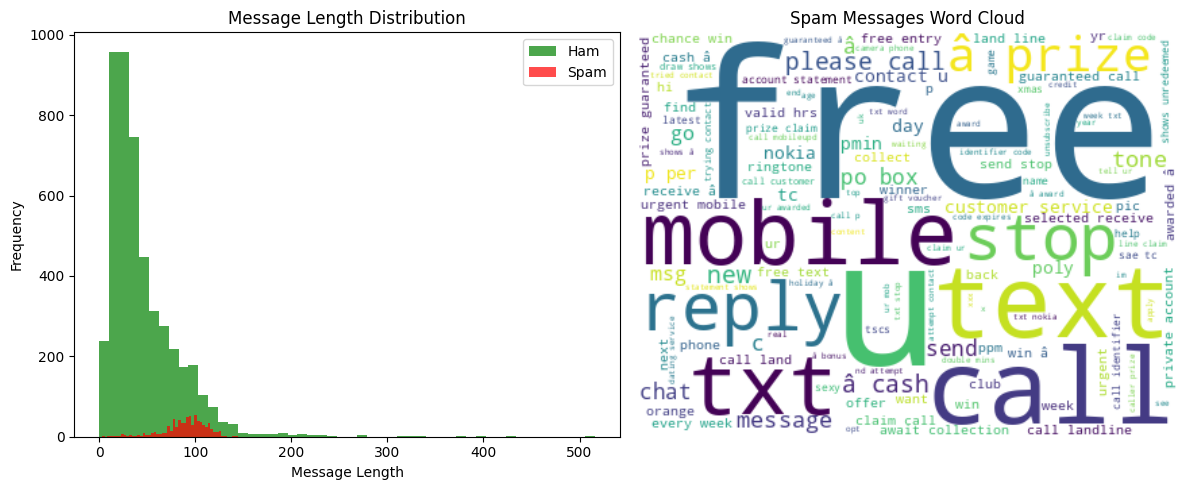

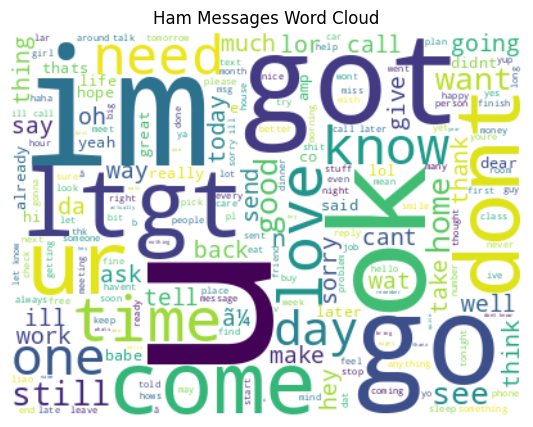

In [4]:
# Cell 4: Exploratory Data Analysis

from wordcloud import WordCloud

# Split into spam and ham
spam_messages = data[data['label'] == 'spam']['cleaned_text']
ham_messages = data[data['label'] == 'ham']['cleaned_text']

# Count word frequencies
all_words = ' '.join(data['cleaned_text']).split()
word_freq = pd.Series(all_words).value_counts()

# Display top words
print("="*50)
print("📊 EXPLORATORY DATA ANALYSIS")
print("="*50)

print("\n🔝 Top 10 most common words:")
print(word_freq.head(10))

print("\n📏 Message length analysis:")
data['length'] = data['cleaned_text'].str.len()
print(f"Average length (ham): {data[data['label'] == 'ham']['length'].mean():.2f}")
print(f"Average length (spam): {data[data['label'] == 'spam']['length'].mean():.2f}")

# Visualize message length distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(data[data['label'] == 'ham']['length'], bins=50, alpha=0.7, label='Ham', color='green')
plt.hist(data[data['label'] == 'spam']['length'], bins=50, alpha=0.7, label='Spam', color='red')
plt.xlabel('Message Length')
plt.ylabel('Frequency')
plt.title('Message Length Distribution')
plt.legend()

# Word Cloud - Spam
plt.subplot(1, 2, 2)
spam_text = ' '.join(spam_messages)
spam_wordcloud = WordCloud(width=400, height=300, background_color='white').generate(spam_text)
plt.imshow(spam_wordcloud, interpolation='bilinear')
plt.title('Spam Messages Word Cloud')
plt.axis('off')

plt.tight_layout()
plt.show()

# Word Cloud - Ham
plt.figure(figsize=(12, 5))
ham_text = ' '.join(ham_messages)
ham_wordcloud = WordCloud(width=400, height=300, background_color='white').generate(ham_text)
plt.imshow(ham_wordcloud, interpolation='bilinear')
plt.title('Ham Messages Word Cloud')
plt.axis('off')
plt.show()

In [5]:
# Cell 5: Split data and create features

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

# Split data
X = data['cleaned_text']
y = data['label_num']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("="*50)
print("📊 DATA SPLIT")
print("="*50)
print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Train spam ratio: {y_train.sum() / len(y_train) * 100:.2f}%")
print(f"Test spam ratio: {y_test.sum() / len(y_test) * 100:.2f}%")

# Create vectorizers
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    stop_words='english'
)

count_vectorizer = CountVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    stop_words='english'
)

# Transform training data
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_train_count = count_vectorizer.fit_transform(X_train)

# Transform test data
X_test_tfidf = tfidf_vectorizer.transform(X_test)
X_test_count = count_vectorizer.transform(X_test)

print(f"\n✅ TF-IDF Features: {X_train_tfidf.shape}")
print(f"✅ Count Features: {X_train_count.shape}")

📊 DATA SPLIT
Training samples: 4457
Test samples: 1115
Train spam ratio: 13.42%
Test spam ratio: 13.36%

✅ TF-IDF Features: (4457, 5000)
✅ Count Features: (4457, 5000)


In [6]:
# Cell 6: Train and compare multiple models

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# Define models to test
models = {
    'Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM': SVC(kernel='linear', random_state=42, probability=True),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

# Store results
results = {}

print("="*50)
print("🚀 TRAINING MODELS")
print("="*50)

for name, model in models.items():
    print(f"\n📊 Training {name}...")

    # Train on TF-IDF features
    model.fit(X_train_tfidf, y_train)

    # Predict
    y_pred = model.predict(X_test_tfidf)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results[name] = {
        'model': model,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'y_pred': y_pred
    }

    print(f"  ✅ Accuracy: {accuracy:.4f}")
    print(f"  ✅ Precision: {precision:.4f}")
    print(f"  ✅ Recall: {recall:.4f}")
    print(f"  ✅ F1-Score: {f1:.4f}")

# Find best model
best_model_name = max(results, key=lambda x: results[x]['accuracy'])
best_model = results[best_model_name]['model']
best_y_pred = results[best_model_name]['y_pred']

print("\n" + "="*50)
print(f"🏆 BEST MODEL: {best_model_name}")
print(f"   Accuracy: {results[best_model_name]['accuracy']:.4f}")
print("="*50)

🚀 TRAINING MODELS

📊 Training Naive Bayes...
  ✅ Accuracy: 0.9659
  ✅ Precision: 1.0000
  ✅ Recall: 0.7450
  ✅ F1-Score: 0.8538

📊 Training Logistic Regression...
  ✅ Accuracy: 0.9668
  ✅ Precision: 1.0000
  ✅ Recall: 0.7517
  ✅ F1-Score: 0.8582

📊 Training SVM...
  ✅ Accuracy: 0.9812
  ✅ Precision: 0.9776
  ✅ Recall: 0.8792
  ✅ F1-Score: 0.9258

📊 Training Random Forest...
  ✅ Accuracy: 0.9740
  ✅ Precision: 0.9839
  ✅ Recall: 0.8188
  ✅ F1-Score: 0.8938

🏆 BEST MODEL: SVM
   Accuracy: 0.9812


📊 EVALUATION REPORT - SVM

📋 Classification Report:
              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       966
        Spam       0.98      0.88      0.93       149

    accuracy                           0.98      1115
   macro avg       0.98      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115


📊 Confusion Matrix:
[[963   3]
 [ 18 131]]


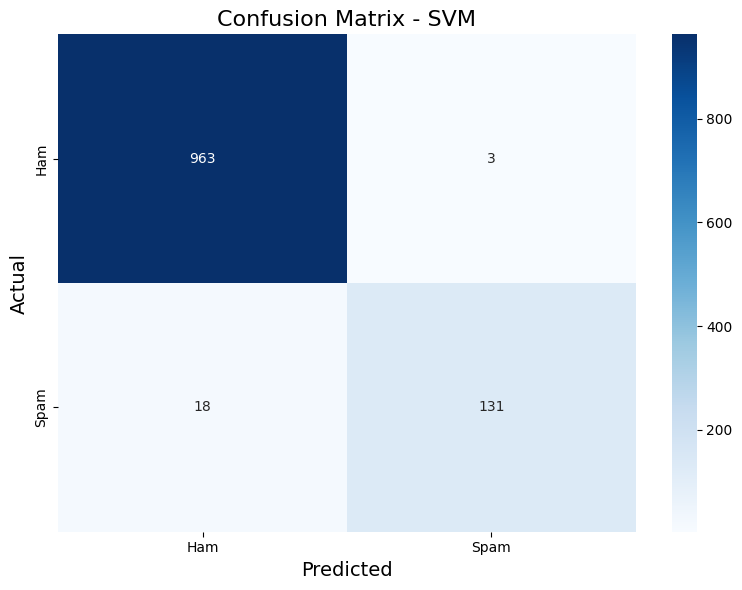

✅ Classification report saved to classification_report.txt


In [7]:
# Cell 7: Detailed evaluation of best model

from sklearn.metrics import confusion_matrix, classification_report

# Use best model
best_model_name = max(results, key=lambda x: results[x]['accuracy'])
best_y_pred = results[best_model_name]['y_pred']

print("="*50)
print(f"📊 EVALUATION REPORT - {best_model_name}")
print("="*50)

# Classification Report
print("\n📋 Classification Report:")
print(classification_report(y_test, best_y_pred, target_names=['Ham', 'Spam']))

# Confusion Matrix
cm = confusion_matrix(y_test, best_y_pred)
print("\n📊 Confusion Matrix:")
print(cm)

# Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted', fontsize=14)
plt.ylabel('Actual', fontsize=14)
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=16)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300)
plt.show()

# Save all metrics to a text file
with open('classification_report.txt', 'w') as f:
    f.write("="*50 + "\n")
    f.write(f"SPAM SMS CLASSIFIER - {best_model_name}\n")
    f.write("="*50 + "\n\n")
    f.write(classification_report(y_test, best_y_pred, target_names=['Ham', 'Spam']))
    f.write("\n\nConfusion Matrix:\n")
    f.write(str(cm))

print("✅ Classification report saved to classification_report.txt")

In [8]:
# Cell 8: Test with custom examples

# Create sample messages (10+ examples)
test_messages = [
    # Ham messages
    "Hey, are we still meeting for lunch tomorrow?",
    "Can you please send me the report by 5 PM?",
    "I'll call you later tonight",
    "Thanks for your help! I really appreciate it",
    "Don't forget to bring the documents to the meeting",
    "Happy Birthday! Hope you have a wonderful day",

    # Spam messages
    "CONGRATULATIONS! You've won a free iPhone! Click here to claim now",
    "URGENT: Your bank account has been compromised. Call immediately",
    "You have won $1,000,000 in our lottery. Send your bank details",
    "Free tickets to Disneyland! Reply with your email address",
    "Earn $5000 per day working from home. No experience needed",
    "Claim your exclusive discount now! Limited time offer",
    "Your account has been suspended. Verify your identity now",
    "Investment opportunity: Double your money in 30 days!",
    "You've been selected for a free vacation. Call now!",
    "Get rich quick! Join our exclusive program today"
]

# Create function for prediction with confidence
def predict_with_confidence(texts):
    """
    Predict spam/ham with confidence scores
    """
    # Clean texts
    cleaned_texts = [clean_text(text) for text in texts]
    cleaned_texts = [remove_stopwords(text) for text in cleaned_texts]

    # Vectorize
    texts_tfidf = tfidf_vectorizer.transform(cleaned_texts)

    # Get predictions
    predictions = best_model.predict(texts_tfidf)

    # Get probabilities
    if hasattr(best_model, 'predict_proba'):
        probabilities = best_model.predict_proba(texts_tfidf)
        confidence = np.max(probabilities, axis=1)
    else:
        # For models without predict_proba (like SVM without probability=True)
        confidence = np.ones_like(predictions)  # Placeholder

    return predictions, confidence

# Make predictions
predictions, confidence = predict_with_confidence(test_messages)

# Display results
print("="*60)
print("📊 SAMPLE PREDICTIONS - 10+ Test Examples")
print("="*60)

results_df = pd.DataFrame({
    'Message': test_messages[:10],  # Show first 10
    'Prediction': ['SPAM' if pred == 1 else 'HAM' for pred in predictions[:10]],
    'Confidence': confidence[:10]
})

print(results_df.to_string(index=True))

# Detailed view
print("\n" + "="*60)
print("📋 DETAILED PREDICTIONS")
print("="*60)

for i, (msg, pred, conf) in enumerate(zip(test_messages, predictions, confidence)):
    label = "🚨 SPAM" if pred == 1 else "✅ HAM"
    conf_percent = conf * 100
    status = "HIGH CONFIDENCE" if conf_percent > 90 else "MEDIUM CONFIDENCE" if conf_percent > 70 else "LOW CONFIDENCE"
    print(f"{i+1}. {label} ({conf_percent:.1f}% - {status})")
    print(f"   \"{msg[:50]}...\"")
    print()

# Save predictions to file
with open('sample_predictions.txt', 'w') as f:
    f.write("="*60 + "\n")
    f.write("SPAM SMS CLASSIFIER - SAMPLE PREDICTIONS\n")
    f.write("="*60 + "\n\n")
    for i, (msg, pred, conf) in enumerate(zip(test_messages, predictions, confidence)):
        label = "SPAM" if pred == 1 else "HAM"
        f.write(f"{i+1}. {label} ({conf*100:.1f}%)\n")
        f.write(f"   {msg}\n\n")

📊 SAMPLE PREDICTIONS - 10+ Test Examples
                                                              Message Prediction  Confidence
0                       Hey, are we still meeting for lunch tomorrow?        HAM    0.999876
1                          Can you please send me the report by 5 PM?        HAM    0.970228
2                                         I'll call you later tonight        HAM    0.999575
3                        Thanks for your help! I really appreciate it        HAM    0.980586
4                  Don't forget to bring the documents to the meeting        HAM    0.984846
5                       Happy Birthday! Hope you have a wonderful day        HAM    0.998235
6  CONGRATULATIONS! You've won a free iPhone! Click here to claim now       SPAM    0.992475
7    URGENT: Your bank account has been compromised. Call immediately       SPAM    0.914245
8      You have won $1,000,000 in our lottery. Send your bank details        HAM    0.927990
9           Free tickets to D

In [9]:
# Cell 9: Complete Inference Pipeline

class SpamClassifier:
    """
    Spam SMS/Email Classifier for inference
    """
    def __init__(self, model, vectorizer):
        self.model = model
        self.vectorizer = vectorizer
        self.class_names = ['Ham', 'Spam']

    def preprocess(self, text):
        """Clean and preprocess text"""
        text = clean_text(text)
        text = remove_stopwords(text)
        return text

    def predict(self, text):
        """Predict single message"""
        # Preprocess
        cleaned = self.preprocess(text)

        # Vectorize
        vectorized = self.vectorizer.transform([cleaned])

        # Predict
        pred = self.model.predict(vectorized)[0]

        # Get probability
        if hasattr(self.model, 'predict_proba'):
            proba = self.model.predict_proba(vectorized)[0]
            confidence = np.max(proba)
            confidence_scores = {
                'Ham': proba[0],
                'Spam': proba[1]
            }
        else:
            confidence = 1.0
            confidence_scores = None

        return {
            'text': text,
            'prediction': self.class_names[pred],
            'is_spam': bool(pred),
            'confidence': confidence,
            'confidence_scores': confidence_scores
        }

    def predict_batch(self, texts):
        """Predict multiple messages"""
        results = []
        for text in texts:
            results.append(self.predict(text))
        return results

    def predict_with_threshold(self, text, threshold=0.7):
        """Predict with confidence threshold"""
        result = self.predict(text)
        if result['confidence'] < threshold:
            result['prediction'] = 'Uncertain'
            result['is_spam'] = None
        return result

# Create inference object
classifier = SpamClassifier(best_model, tfidf_vectorizer)

# Test with a new message
test_text = "WINNER!! You have been selected for a free cruise trip! Reply YES to claim"
result = classifier.predict(test_text)
print("🔍 Single Prediction Test:")
print(f"Message: {test_text}")
print(f"Prediction: {result['prediction']}")
print(f"Confidence: {result['confidence']:.2%}")
print(f"Confidence Scores: {result['confidence_scores']}")

# Save the classifier
import joblib

# Create directory
os.makedirs('models', exist_ok=True)

# Save model and vectorizer
joblib.dump(best_model, 'models/spam_classifier.pkl')
joblib.dump(tfidf_vectorizer, 'models/tfidf_vectorizer.pkl')

print("\n✅ Model and vectorizer saved to models/")

🔍 Single Prediction Test:
Message: WINNER!! You have been selected for a free cruise trip! Reply YES to claim
Prediction: Spam
Confidence: 100.00%
Confidence Scores: {'Ham': np.float64(6.800415314126513e-06), 'Spam': np.float64(0.9999931995846859)}

✅ Model and vectorizer saved to models/


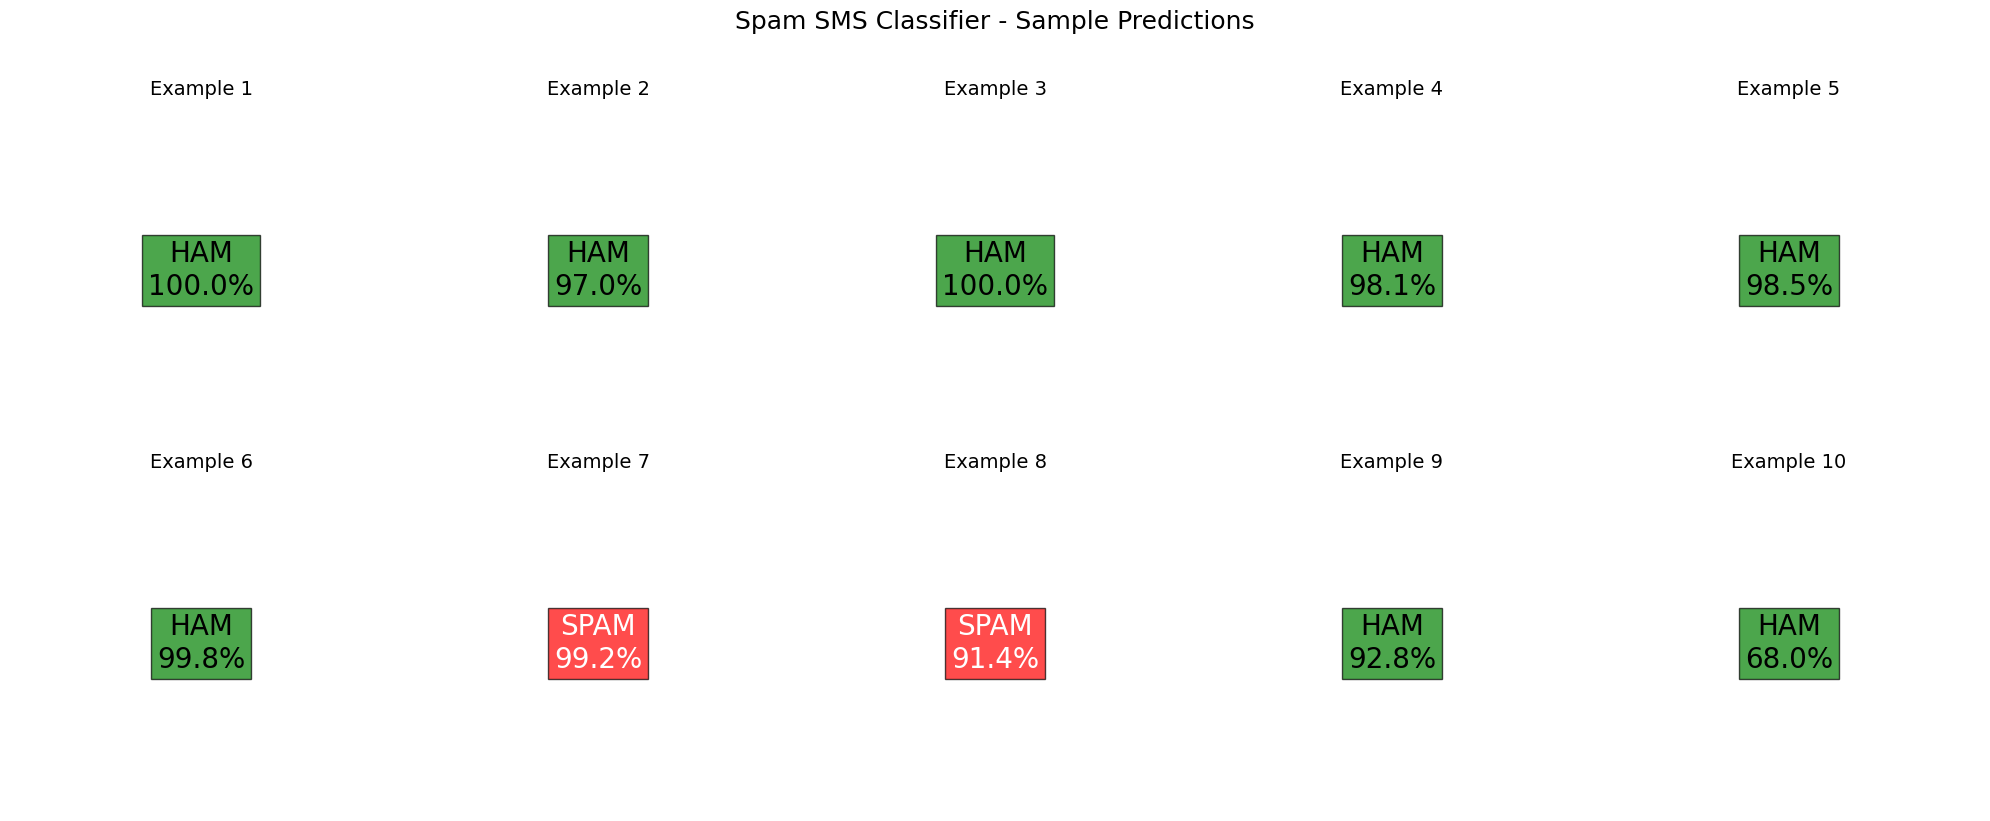

	zip warning: name not matched: *.ipynb
  adding: outputs/ (stored 0%)
  adding: outputs/confusion_matrix/ (stored 0%)
  adding: outputs/confusion_matrix/confusion_matrix.png (deflated 30%)
  adding: outputs/metrics/ (stored 0%)
  adding: outputs/metrics/classification_report.txt (deflated 60%)
  adding: outputs/sample_predictions/ (stored 0%)
  adding: outputs/sample_predictions/predictions.png (deflated 39%)
  adding: models/ (stored 0%)
  adding: models/spam_classifier.pkl (deflated 44%)
  adding: models/tfidf_vectorizer.pkl (deflated 74%)
✅ All results saved to spam_classifier_results.zip


In [10]:
# Cell 10: Save all results and create output structure

# Create outputs folder
os.makedirs('outputs/metrics', exist_ok=True)
os.makedirs('outputs/confusion_matrix', exist_ok=True)
os.makedirs('outputs/sample_predictions', exist_ok=True)

# Move files to outputs
!mv confusion_matrix.png outputs/confusion_matrix/
!mv classification_report.txt outputs/metrics/

# Create sample predictions visualization
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, (msg, pred, conf) in enumerate(zip(test_messages[:10], predictions[:10], confidence[:10])):
    ax = axes[i]
    # Create a simple text box
    text = f"{'SPAM' if pred == 1 else 'HAM'}\n{conf*100:.1f}%"
    ax.text(0.5, 0.5, text,
            ha='center', va='center',
            fontsize=20,
            color='white' if pred == 1 else 'black',
            bbox=dict(facecolor='red' if pred == 1 else 'green', alpha=0.7))
    ax.set_title(f"Example {i+1}", fontsize=14)
    ax.axis('off')

plt.suptitle('Spam SMS Classifier - Sample Predictions', fontsize=18, y=1.02)
plt.tight_layout()
plt.savefig('outputs/sample_predictions/predictions.png', dpi=300)
plt.show()

# Save all outputs as zip
!zip -r spam_classifier_results.zip outputs/ models/ *.ipynb

print("✅ All results saved to spam_classifier_results.zip")

In [11]:
# Cell 11: Download results

from google.colab import files
files.download('spam_classifier_results.zip')

print("✅ Results downloaded successfully!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Results downloaded successfully!
